In [1]:
#Importing Required Libraries
import numpy as np, pandas as pd
import seaborn as sns,matplotlib.pyplot as plt
import os 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
#Loading Datasets
t_data=pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test=pd.read_csv('/kaggle/input/competitions/titanic/test.csv')


In [3]:
#Categorizing The Data
t_data['train_test']=1
test['train_test']=0
test['Survived']=np.nan
d_set=pd.concat([t_data,test])

In [4]:
%matplotlib inline

In [5]:
d_set.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_test'],
      dtype='object')

**Data Exploration**

In [6]:
t_data.info() #Quick Lookup To The Dataset
t_data.describe() #For Better Insight At Numeric Data
t_data.describe().columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  train_test   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'train_test'],
      dtype='object')

In [7]:
df_num=t_data[['Age','SibSp','Parch','Fare']]
df_cat=t_data[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

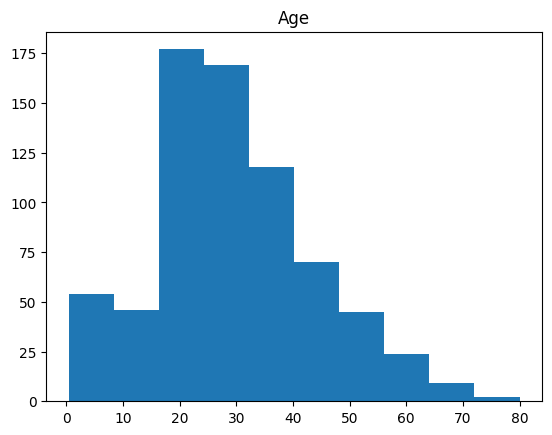

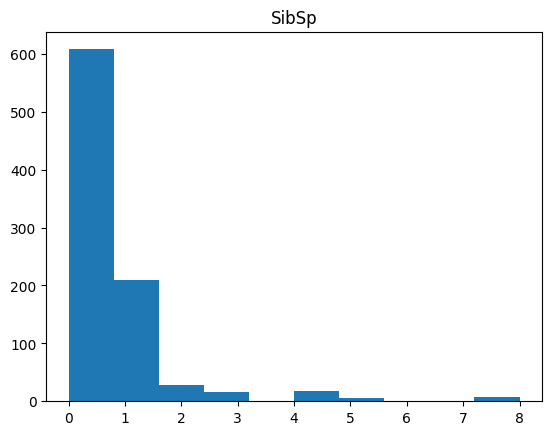

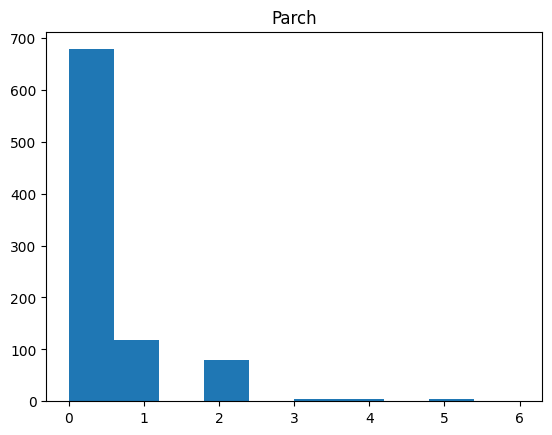

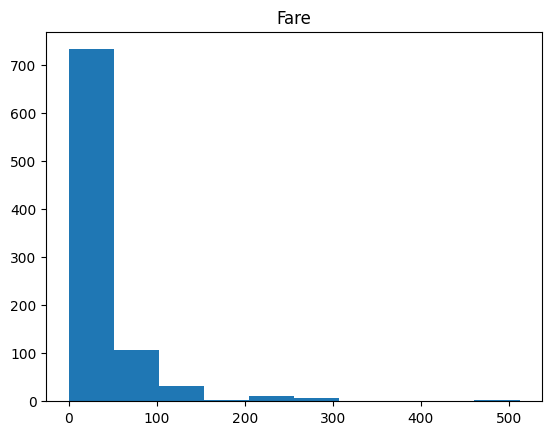

In [8]:
#Plots For The Distribution For All Numeric Variables
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

            Age     SibSp     Parch      Fare
Age    1.000000 -0.308247 -0.189119  0.096067
SibSp -0.308247  1.000000  0.414838  0.159651
Parch -0.189119  0.414838  1.000000  0.216225
Fare   0.096067  0.159651  0.216225  1.000000


<Axes: >

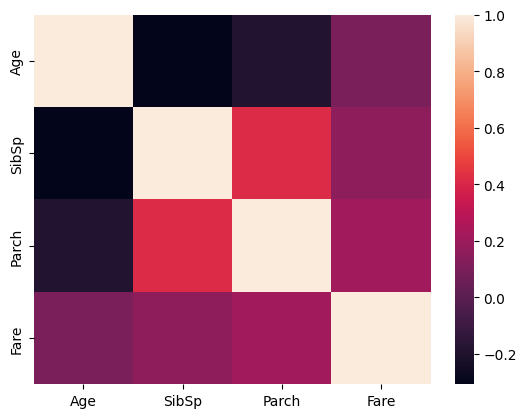

In [9]:
print(df_num.corr())
sns.heatmap(df_num.corr())

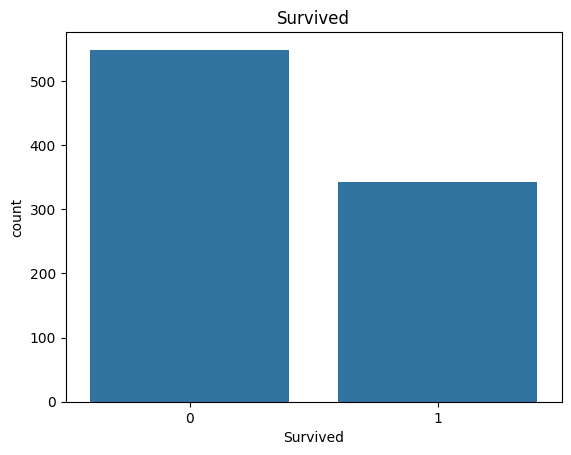

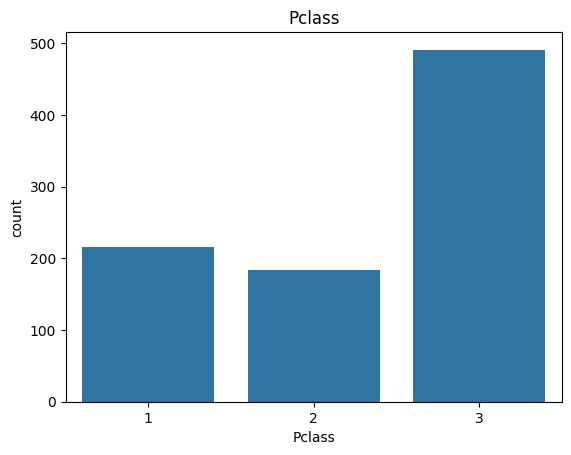

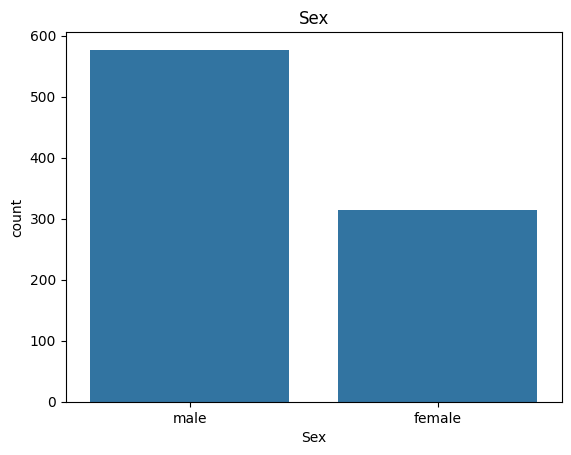

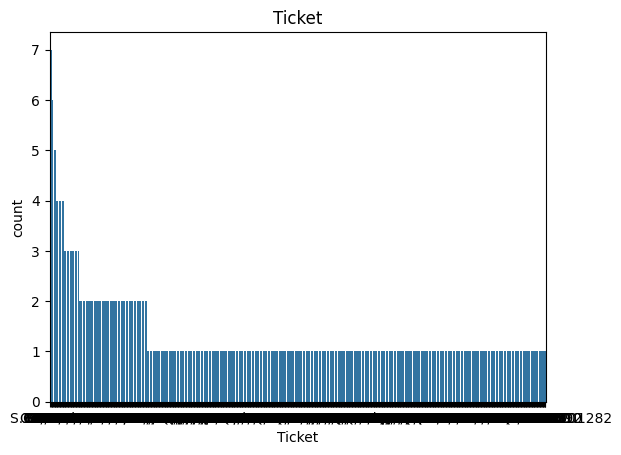

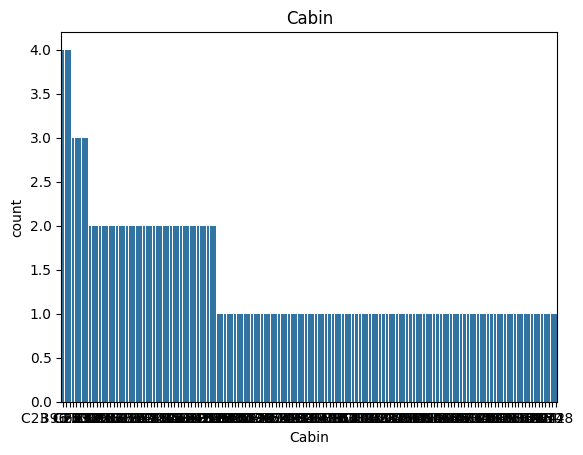

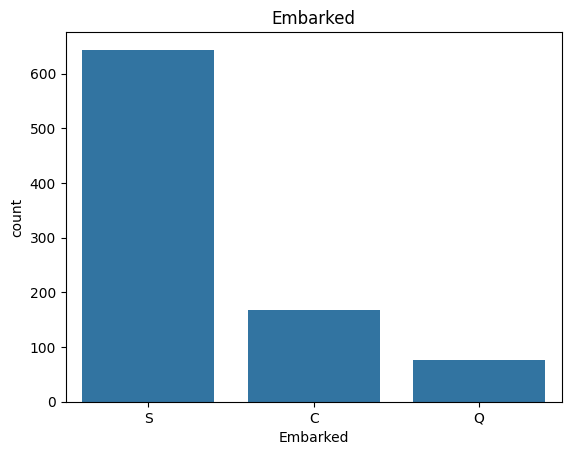

In [10]:
#Comparing Survival Rates Across Age,SibSp,Parch And Fare
pd.pivot_table(
    t_data,
    index='Survived',
    values=['Age','SibSp','Parch','Fare'])
for i in df_cat.columns:
    sns.barplot(
        x=df_cat[i].value_counts().index,
        y=df_cat[i].value_counts()
    ).set_title(i)
    plt.show()

In [11]:
#Comparing Survival And Other Variables
print(pd.pivot_table(t_data,index='Survived',columns='Pclass',values='Ticket',aggfunc='count'))
print()
print(pd.pivot_table(t_data,index='Survived',columns='Sex',values='Ticket',aggfunc='count'))
print()
print(pd.pivot_table(t_data,index='Survived',columns='Embarked',values='Ticket',aggfunc='count'))

Pclass      1   2    3
Survived              
0          80  97  372
1         136  87  119

Sex       female  male
Survived              
0             81   468
1            233   109

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217


**Feature Engineering**

Simplifying Cabins

In [12]:
df_cat.Cabin
t_data['cabin_multiple']=t_data.Cabin.apply(lambda x:0 if pd.isna(x) else len(x.split(' ')))
t_data['cabin_multiple'].value_counts()

pd.pivot_table(t_data,index='Survived',columns='cabin_multiple',values='Ticket',aggfunc='count')

cabin_multiple,0,1,2,3,4
Survived,,,,,
0,481.0,58.0,7.0,3.0,NaN
1,206.0,122.0,9.0,3.0,2.0


In [13]:
#Creating Categories Based On First Letter Of Cabin
t_data['cabin_adv']=t_data.Cabin.apply(lambda x:str(x)[0])

In [14]:
#Comparing Survival Rate By Cabin
print(t_data.cabin_adv.value_counts())
pd.pivot_table(t_data,index='Survived',columns='cabin_adv',values='Name',aggfunc='count')

cabin_adv
n    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


cabin_adv,A,B,C,D,E,F,G,T,n
Survived,,,,,,,,,
0,8.0,12.0,24.0,8.0,8.0,5.0,2.0,1.0,481.0
1,7.0,35.0,35.0,25.0,24.0,8.0,2.0,NaN,206.0


In [15]:
t_data['numeric_ticket']=t_data.Ticket.apply(lambda x: 1 if x.isnumeric() else 0)
t_data['ticket_letters']=t_data.Ticket.apply(lambda x:''.join(x.split(' ')[:-1]).replace('.','').replace('/','').lower() if len(x.split(' ')[:-1])>0 else 0)
t_data['numeric_ticket'].value_counts()

numeric_ticket
1    661
0    230
Name: count, dtype: int64

In [16]:
#Difference In Numeric Vs Non-Numeric Tickets In Survival Rates
pd.pivot_table(t_data,index='Survived',columns='numeric_ticket',values='Ticket',aggfunc='count')


numeric_ticket,0,1
Survived,,
0,142,407
1,88,254


Do Different Ticket Types Impact Survival Rates?

In [17]:
#Survival Rate Across Different Ticket Types
pd.pivot_table(t_data,index='Survived',columns='ticket_letters',values='Ticket',aggfunc='count')

ticket_letters,0,a4,a5,as,c,ca,casoton,fa,fc,fcc,...,soc,sop,sopp,sotono2,sotonoq,sp,stono2,swpp,wc,wep
Survived,,,,,,,,,,,,,,,,,,,,,
0,410.0,7.0,19.0,1.0,3.0,27.0,1.0,1.0,1.0,1.0,...,5.0,1.0,3.0,2.0,13.0,1.0,10.0,NaN,9.0,2.0
1,255.0,NaN,2.0,NaN,2.0,14.0,NaN,NaN,NaN,4.0,...,1.0,NaN,NaN,NaN,2.0,NaN,8.0,2.0,1.0,1.0


Does A Person's Title Relate To Survival Rates?

In [18]:
#Feature Engineering On Person's Title
t_data['name_title']=t_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())
t_data['name_title'].value_counts()

name_title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Data Preprocessing

In [19]:
#Creating All Categorical Variables 
d_set['cabin_multiple']=d_set.Cabin.apply(lambda x:0 if pd.isna(x) else len(x.split(' ')))
d_set['cabin_adv']=d_set.Cabin.apply(lambda x:str(x)[0])
d_set['numeric_ticket']=d_set.Ticket.apply(lambda x:1 if x.isnumeric() else 0)
d_set['ticket_letters']=d_set.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.','').replace('/','').lower() if len(x.split(' ')[:-1])>0 else 0)
d_set['name_title']=d_set.Name.apply(lambda x:x.split(',')[1].split('.')[0].strip())

In [20]:
#For Continous Data,Filling Nulls
d_set.Age=d_set.Age.fillna(t_data.Age.median())
d_set.Fare=d_set.Fare.fillna(t_data.Fare.median())

#Dropping Null In 'embarked' Rows. 
#Only 2 Instances Of This In Training Set And 0 In Testing Set
d_set.dropna(subset=['Embarked'],inplace=True)

<Axes: >

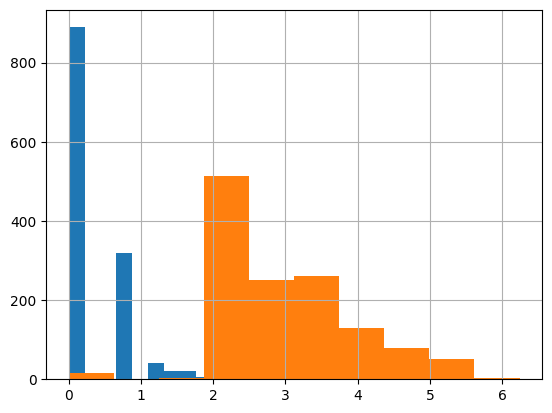

In [21]:
#log Norm Of Rows
d_set['norm_sibsp']=np.log(d_set.SibSp+1)
d_set['norm_sibsp'].hist() #Not Used

d_set['norm_fare']=np.log(d_set.Fare+1)
d_set['norm_fare'].hist() #Used

In [22]:
#Category For pd.get_dummies()
d_set.Pclass = d_set.Pclass.astype(str)
#Dummy Variables From Categories
dummy=pd.get_dummies(d_set[['Pclass','Sex','Age','SibSp','Parch','norm_fare','Embarked','cabin_adv','cabin_multiple','numeric_ticket','name_title','train_test']])

In [23]:
#Splitting To Train-Test 
x_train=dummy[dummy.train_test==1].drop(['train_test'],axis=1)
x_test=dummy[dummy.train_test==0].drop(['train_test'],axis=1)

y_train=d_set[d_set.train_test==1].Survived
y_train.shape

(889,)

In [24]:
#Scaling The Data
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
dummy_scale=dummy.copy()
dummy_scale[['Age','SibSp','Parch','norm_fare']]= scale.fit_transform(dummy_scale[['Age','SibSp','Parch','norm_fare']])
dummy_scale

x_train_scaled=dummy_scale[dummy_scale.train_test==1].drop(['train_test'],axis=1)
x_test_scaled=dummy_scale[dummy_scale.train_test == 0].drop(['train_test'],axis=1)

y_train=d_set[d_set.train_test==1].Survived

**Model Building**

In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [26]:
#Using Naive Bayes As A Baseline For Classification Task
gnb=GaussianNB()
cv=cross_val_score(gnb,x_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.66853933 0.70224719 0.75842697 0.74719101 0.73446328]
0.7221735542436362


Logistic Regression Model

In [27]:
lr=LogisticRegression(max_iter=2000)
cv=cross_val_score(lr,x_train,y_train,cv=5)
print(cv)
print(cv.mean())

#For Scaled Data
lr=LogisticRegression(max_iter=2000)
cv=cross_val_score(lr,x_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.8258427  0.80898876 0.80337079 0.82022472 0.85310734]
0.8223068621849807
[0.8258427  0.80898876 0.80337079 0.82022472 0.85310734]
0.8223068621849807


Decision Tree Classifier

In [28]:
dt=tree.DecisionTreeClassifier(random_state=1)
cv=cross_val_score(dt,x_train,y_train,cv=5)
print(cv)
print(cv.mean())

#For Scaled Data
dt=tree.DecisionTreeClassifier(random_state=1)
cv=cross_val_score(dt,x_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.75842697 0.74719101 0.8258427  0.74719101 0.8079096 ]
0.7773122579826065
[0.75842697 0.74719101 0.8258427  0.74719101 0.8079096 ]
0.7773122579826065


KNN Model

In [29]:
knn=KNeighborsClassifier()
cv=cross_val_score(knn,x_train,y_train,cv=5)
print(cv)
print(cv.mean())

#For Scaled Data
knn=KNeighborsClassifier()
cv=cross_val_score(knn,x_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.76966292 0.79775281 0.80898876 0.82022472 0.85310734]
0.8099473116231829
[0.79775281 0.78651685 0.83146067 0.79775281 0.85310734]
0.8133180981400369


Random Forest Classifier Model

In [30]:
rf=RandomForestClassifier(random_state=1)
cv=cross_val_score(rf,x_train,y_train,cv=5)
print(cv)
print(cv.mean())

#For Scaled Data
rf=RandomForestClassifier(random_state=1)
cv=cross_val_score(rf,x_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.80898876 0.79213483 0.84831461 0.73595506 0.82485876]
0.8020504030978227
[0.80337079 0.79213483 0.84831461 0.73595506 0.82485876]
0.8009268075922046


SVM Model

In [31]:
svc=SVC(probability=True)
cv=cross_val_score(svc,x_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.85393258 0.82022472 0.8258427  0.80337079 0.86440678]
0.8335555132355742


XG Boosting Model

In [32]:
from xgboost import XGBClassifier
xgb=XGBClassifier(random_state=1)
cv=cross_val_score(xgb,x_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.81460674 0.80898876 0.86516854 0.79775281 0.81920904]
0.8211451786961215


In [33]:
#Voting Classifier Takes All Of The Inputs And Averages The Results.
#A "Hard" Voting Classifier Gets 1 Vote "yes" or "no" Per Classifier And The Result Is Just A Popular Vote. For this, you generally want odd numbers
#A "Soft" Classifier Averages The Confidence Of Each Of The Models.If A The Average Confidence Is >50% That Its A 1 It'll Be Counted As Such
from sklearn.ensemble import VotingClassifier
vot_clf=VotingClassifier(estimators=[('lr',lr),('knn',knn),('rf',rf),('gnb',gnb),('svc',svc),('xgb',xgb)],voting='soft') 

In [34]:
cv=cross_val_score(vot_clf,x_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.82022472 0.81460674 0.82022472 0.79775281 0.84745763]
0.8200533231765377


In [35]:
vot_clf.fit(x_train_scaled,y_train)
y_hat_base_vc=vot_clf.predict(x_test_scaled).astype(int)
basic_submission={'PassengerId':test.PassengerId,'Survived':y_hat_base_vc}
base_submission=pd.DataFrame(data=basic_submission)
base_submission.to_csv('base_submission.csv',index=False)

**Model Tuned Performance**

In [36]:
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV 

In [37]:
#Function For Performance Reports
def clf_performance(clf,mdl):
    print(mdl)
    print('Best Score: '+str(clf.best_score_))
    print('Best Parameters: '+str(clf.best_params_))

Tuned Models Below

In [38]:
lr=LogisticRegression()
param_grid={'max_iter':[2000],
            'penalty':['l1','l2'],
            'C':np.logspace(-4,4,20),
            'solver':['liblinear']}

clf_lr=GridSearchCV(lr,param_grid=param_grid,cv=5,verbose=True,n_jobs=-1)
best_clf_lr=clf_lr.fit(x_train_scaled,y_train)
clf_performance(best_clf_lr,'Logistic Regression')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Logistic Regression
Best Score: 0.8279375357074843
Best Parameters: {'C': np.float64(1.623776739188721), 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}


In [39]:
knn=KNeighborsClassifier()
param_grid={'n_neighbors':[3,5,7,9],
              'weights':['uniform','distance'],
              'algorithm':['auto','ball_tree','kd_tree'],
              'p' : [1,2]}
clf_knn=GridSearchCV(knn,param_grid=param_grid,cv=5,verbose=True,n_jobs=-1)
best_clf_knn=clf_knn.fit(x_train_scaled,y_train)
clf_performance(best_clf_knn,'KNN')

Fitting 5 folds for each of 48 candidates, totalling 240 fits
KNN
Best Score: 0.8290611312131023
Best Parameters: {'algorithm': 'ball_tree', 'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}


In [40]:
svc=SVC(probability=True)
param_grid=tuned_parameters=[{'kernel':['rbf'],'gamma':[.1,.5,1,2,5,10],
                              'C':[.1,1,10,100,1000]},
                             {'kernel':['linear'],'C':[.1,1,10,100,1000]},
                            {'kernel':['poly'],'degree':[2,3,4,5],'C':[.1,1,10,100,1000]}]
clf_svc=GridSearchCV(svc,param_grid=param_grid,cv=5,verbose=True,n_jobs=-1)
best_clf_svc=clf_svc.fit(x_train_scaled,y_train)
clf_performance(best_clf_svc,'SVC')


Fitting 5 folds for each of 55 candidates, totalling 275 fits
SVC
Best Score: 0.8335555132355742
Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


In [41]:
#For Random Forest Classifier,The Total Feature Space Is Too Large
#So To Narrow Down The Parameters, Performing Granular Search
rf=RandomForestClassifier(random_state=1)
param_grid={'n_estimators':[400,450,500,550],
            'criterion':['gini','entropy'],
                        'bootstrap':[True],
                        'max_depth':[15,20,25],
                        'max_features':['auto','sqrt',10],
                        'min_samples_leaf':[2,3],
                        'min_samples_split':[2,3]}
                                  
clf_rf=GridSearchCV(rf,param_grid=param_grid,cv=5,verbose=True,n_jobs=-1)
best_clf_rf=clf_rf.fit(x_train_scaled,y_train)
clf_performance(best_clf_rf,'Random Forest')

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
480 fits failed out of a total of 1440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
378 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

Random Forest
Best Score: 0.8358027042468101
Best Parameters: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 15, 'max_features': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 550}


<Axes: >

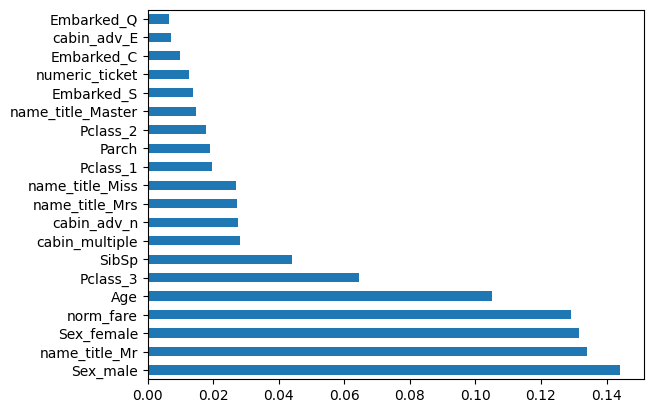

In [42]:
best_rf=best_clf_rf.best_estimator_.fit(x_train_scaled,y_train)
feat_importances=pd.Series(best_rf.feature_importances_,index=x_train_scaled.columns)
feat_importances.nlargest(20).plot(kind='barh')

In [43]:
xgb=XGBClassifier(random_state=1)
param_grid={
    'n_estimators':[450,500,550],
    'colsample_bytree':[0.75,0.8,0.85],
    'max_depth':[None],
    'reg_alpha':[1],
    'reg_lambda':[2,5,10],
    'subsample':[0.55,0.6,.65],
    'learning_rate':[0.5],
    'gamma':[.5,1,2],
    'min_child_weight':[0.01],
    'sampling_method':['uniform']
}
clf_xgb=GridSearchCV(xgb,param_grid=param_grid,cv=5,verbose=True,n_jobs=-1)
best_clf_xgb=clf_xgb.fit(x_train_scaled,y_train)
clf_performance(best_clf_xgb,'XGB')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
XGB
Best Score: 0.851520345331048
Best Parameters: {'colsample_bytree': 0.75, 'gamma': 0.5, 'learning_rate': 0.5, 'max_depth': None, 'min_child_weight': 0.01, 'n_estimators': 550, 'reg_alpha': 1, 'reg_lambda': 10, 'sampling_method': 'uniform', 'subsample': 0.65}


In [44]:
y_hat_xgb=best_clf_xgb.best_estimator_.predict(x_test_scaled).astype(int)
xgb_submission={'PassengerId':test.PassengerId, 'Survived':y_hat_xgb}
submission_xgb=pd.DataFrame(data=xgb_submission)
submission_xgb.to_csv('xgb_submission3.csv',index=False)

**Ensemble Approaches**

In [45]:
best_lr=best_clf_lr.best_estimator_
best_knn=best_clf_knn.best_estimator_
best_svc=best_clf_svc.best_estimator_
best_rf=best_clf_rf.best_estimator_
best_xgb=best_clf_xgb.best_estimator_

vot_clf_hard=VotingClassifier(estimators=[('knn',best_knn),('rf',best_rf),('svc',best_svc)],voting='hard') 
vot_clf_soft=VotingClassifier(estimators=[('knn',best_knn),('rf',best_rf),('svc',best_svc)],voting='soft') 
vot_clf_all=VotingClassifier(estimators=[('knn',best_knn),('rf',best_rf),('svc',best_svc),('lr',best_lr)],voting = 'soft') 
vot_clf_xgb=VotingClassifier(estimators=[('knn',best_knn),('rf',best_rf),('svc',best_svc),('xgb',best_xgb),('lr',best_lr)],voting='soft')

print('voting_clf_hard :',cross_val_score(vot_clf_hard,x_train,y_train,cv=5))
print('voting_clf_hard mean :',cross_val_score(vot_clf_hard,x_train,y_train,cv=5).mean())

print('voting_clf_soft :',cross_val_score(vot_clf_soft,x_train,y_train,cv=5))
print('voting_clf_soft mean :',cross_val_score(vot_clf_soft,x_train,y_train,cv=5).mean())

print('voting_clf_all :',cross_val_score(vot_clf_all,x_train,y_train,cv=5))
print('voting_clf_all mean :',cross_val_score(vot_clf_all,x_train,y_train,cv=5).mean())

print('voting_clf_xgb :',cross_val_score(vot_clf_xgb,x_train,y_train,cv=5))
print('voting_clf_xgb mean :',cross_val_score(vot_clf_xgb,x_train,y_train,cv=5).mean())

params={'weights':[[1,1,1],[1,2,1],[1,1,2],[2,1,1],[2,2,1],[1,2,2],[2,1,2]]}

vote_weight=GridSearchCV(vot_clf_soft,param_grid=params,cv=5,verbose=True,n_jobs=-1)
best_clf_weight=vote_weight.fit(x_train_scaled,y_train)
clf_performance(best_clf_weight,'VC Weights')
voting_clf_sub=best_clf_weight.best_estimator_.predict(x_test_scaled)

voting_clf_hard : [0.79213483 0.81460674 0.82022472 0.79775281 0.83615819]
voting_clf_hard mean : 0.8121754586427983
voting_clf_soft : [0.78651685 0.81460674 0.81460674 0.79775281 0.85310734]
voting_clf_soft mean : 0.8133180981400369
voting_clf_all : [0.80898876 0.83146067 0.8258427  0.80898876 0.85875706]
voting_clf_all mean : 0.8268075922046595
voting_clf_xgb : [0.83146067 0.8258427  0.83146067 0.80337079 0.86440678]
voting_clf_xgb mean : 0.8301847267187202
Fitting 5 folds for each of 7 candidates, totalling 35 fits
VC Weights
Best Score: 0.833568209229988
Best Parameters: {'weights': [2, 2, 1]}


In [46]:
#Making Predictions 
vot_clf_hard.fit(x_train_scaled,y_train)
vot_clf_soft.fit(x_train_scaled,y_train)
vot_clf_all.fit(x_train_scaled,y_train)
vot_clf_xgb.fit(x_train_scaled,y_train)

best_rf.fit(x_train_scaled,y_train)
y_hat_vc_hard=vot_clf_hard.predict(x_test_scaled).astype(int)
y_hat_rf=best_rf.predict(x_test_scaled).astype(int)
y_hat_vc_soft=vot_clf_soft.predict(x_test_scaled).astype(int)
y_hat_vc_all=vot_clf_all.predict(x_test_scaled).astype(int)
y_hat_vc_xgb=vot_clf_xgb.predict(x_test_scaled).astype(int)

In [47]:
#convert output to dataframe 
final_data={'PassengerId':test.PassengerId,'Survived':y_hat_rf}
submission=pd.DataFrame(data=final_data)

final_data_2={'PassengerId':test.PassengerId,'Survived':y_hat_vc_hard}
submission_2=pd.DataFrame(data=final_data_2)

final_data_3={'PassengerId':test.PassengerId,'Survived':y_hat_vc_soft}
submission_3=pd.DataFrame(data=final_data_3)

final_data_4={'PassengerId':test.PassengerId,'Survived':y_hat_vc_all}
submission_4=pd.DataFrame(data=final_data_4)

final_data_5={'PassengerId':test.PassengerId,'Survived':y_hat_vc_xgb}
submission_5=pd.DataFrame(data=final_data_5)

final_data_comp={'PassengerId':test.PassengerId,'Survived_vc_hard':y_hat_vc_hard,'Survived_rf':y_hat_rf,'Survived_vc_soft':y_hat_vc_soft,'Survived_vc_all':y_hat_vc_all,'Survived_vc_xgb':y_hat_vc_xgb}
comparison=pd.DataFrame(data=final_data_comp)

In [48]:
#Tracking Differences Between Outputs 
comparison['difference_rf_vc_hard']=comparison.apply(lambda x:1 if x.Survived_vc_hard!=x.Survived_rf else 0,axis=1)
comparison['difference_soft_hard']=comparison.apply(lambda x:1 if x.Survived_vc_hard!=x.Survived_vc_soft else 0,axis=1)
comparison['difference_hard_all']=comparison.apply(lambda x:1 if x.Survived_vc_all!=x.Survived_vc_hard else 0,axis=1)

In [49]:
comparison.difference_hard_all.value_counts()

difference_hard_all
0    410
1      8
Name: count, dtype: int64

In [50]:
#Preparing Submission Files 
submission.to_csv('submission_rf.csv',index =False)
submission_2.to_csv('submission_vc_hard.csv',index=False)
submission_3.to_csv('submission_vc_soft.csv',index=False)
submission_4.to_csv('submission_vc_all.csv',index=False)
submission_5.to_csv('submission_vc_xgb2.csv',index=False)